In [1]:
import os
import random
import numpy as np
def seed_everything(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ["OMP_NUM_THREADS"] = "1"
    os.environ["MKL_NUM_THREADS"] = "1"
    os.environ["OPENBLAS_NUM_THREADS"] = "1"
    os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
    os.environ["NUMEXPR_NUM_THREADS"] = "1"
    random.seed(seed)
    np.random.seed(seed)
SEED = 42
seed_everything(SEED)

import pandas as pd
import cvxpy as cp
import time
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_svmlight_file
from sklearn.svm import LinearSVC
from matplotlib.ticker import MaxNLocator
from sklearn.preprocessing import normalize

In [2]:
# Spambase Email dataset
data = fetch_openml(name="spambase", version=1, as_frame=False)

X = data.data
y = data.target.astype(int)

y = np.where(y == 1, 1, -1)

scaler = StandardScaler()
X_train2 = scaler.fit_transform(X)
y_train2 = y

norms = np.linalg.norm(X_train2, axis=1, keepdims=True)
X_train2 = X_train2 / norms

**ROBUST SVM**

In [3]:
def train_robust_svm(
        X_train,
        y_train,
        C,
        rho,
        max_iters,
        eps,
        w_init=None,
        use_warm_start=True,
        verbose=False):

    n, d = X_train.shape

    # ----- variables -----
    w = cp.Variable(d)
    t = cp.Variable(nonneg=True)
    xi = cp.Variable(n, nonneg=True)

    y_cp = cp.Constant(y_train)
    rho_cp = cp.Constant(rho)

    # ----- constraints -----
    margin_constraint = (
        1 - cp.multiply(y_cp, X_train @ w)
        + cp.multiply(rho_cp, t)
        <= xi
    )

    soc_constraint = cp.SOC(t, w)

    constraints = [margin_constraint, soc_constraint]

    # ----- objective -----
    objective = cp.Minimize(
        0.5 * cp.square(t) +
        C * cp.sum(xi)
    )

    prob = cp.Problem(objective, constraints)

    # ===== Warm start initialization =====
    if w_init is not None:
        w.value = w_init
        t.value = np.linalg.norm(w_init)

        # khởi tạo xi gần feasible
        margins = y_train * (X_train @ w_init)
        xi.value = np.maximum(0, 1 - margins + rho * t.value)

    start = time.process_time()

    prob.solve(
        solver=cp.SCS,

        max_iters=max_iters,
        eps=eps,
        verbose=verbose,

        acceleration_lookback=1,
        normalize=False,

        warm_start=use_warm_start,

        rho_x=1e-6,
        scale=1e-3,
    )

    end = time.process_time()

    w_val = w.value
    xi_val = xi.value

    # dual variables
    alpha = margin_constraint.dual_value
    alpha = np.clip(alpha, 0, C)

    return w_val, alpha, end - start

**SAFE SCREENIG FOR ROBUST SVM**

In [4]:
# Screening
def screen(X, y, rho, w, R_val, indices, normX_all, Xw):

    idx_array = np.array(indices)

    y_sub = y[idx_array]
    rho_sub = rho[idx_array]
    normX_sub = normX_all[idx_array]

    margins = y_sub * Xw[idx_array]

    w_norm = np.linalg.norm(w)
    w_norm_minus_R = max(w_norm - R_val, 0.0)

    LB = margins - rho_sub*(w_norm + R_val) - R_val*normX_sub
    UB = margins - rho_sub*w_norm_minus_R + R_val*normX_sub

    mask_N = LB > 1.0
    mask_S = UB < 1.0

    N_k = set(idx_array[mask_N])
    S_k = set(idx_array[mask_S])
    F_k_new = set(idx_array[~(mask_N | mask_S)])

    return N_k, S_k, F_k_new

# Dynamic Safe Screening
def dynamic_safe_screening(X, y, rho, C,
                           tol_gap=1e-4, min_F_size=20,
                           initial_reltol=1e-2, final_reltol=1e-6,
                           max_reductions=6,
                           max_iters=2000,
                           verbose=True):
    n, d = X.shape
    normX_all = np.linalg.norm(X, axis=1)
    total_start = time.time()
    all_idx = np.arange(n)
    w_prev = np.zeros(d)

    if verbose:
        print(f"Iter 0: removed 0 |F|={n} |S|=0 |R|=0, gap={0.0} R0={0.0}")

    solve_history = [{
        'iter': 0,
        'F_size': n,
        'primal': 0,
        'dual': 0,
        'gap': 0,
        'Radius': 0,
        'reltol': None,
        'time': time.time()-total_start,
        'screening_rate': 0.0,
        'removed': 0
    }]

    # === Loop for Iter >=1: robust subproblems with screening
    F = set(all_idx)
    R, S = set(), set()
    iteration, reductions, stall_count = 1, 1, 0

    while len(F) > min_F_size and reductions < max_reductions:
        F_list = np.fromiter(F, dtype=int)
        reltol = max(initial_reltol * (0.1 ** reductions), final_reltol)

        # ----- Train robust SVM on F_list set -----
        w_new, alpha, _ = train_robust_svm(
            X_train=X[F_list],
            y_train=y[F_list],
            C=C,
            rho=rho[F_list],
            w_init=w_prev,
            use_warm_start=False,
            max_iters=max_iters,
            eps=reltol
        )
        w_prev = w_new

        # ----- xi, primal, dual và alpha -----
        Xw = X @ w_new
        Xw_F = Xw[F_list]
        X_F = X[F_list]
        y_F = y[F_list]
        rho_F = rho[F_list]
        t_new = np.linalg.norm(w_new)
        xi_new = np.maximum(0, 1 - y_F * Xw_F + rho_F * t_new)
        primal = 0.5 * t_new**2 + C * np.sum(xi_new)

        norm_d = np.linalg.norm(X_F.T @ (alpha * y_F))
        s = np.sum(alpha * rho_F)
        dual = np.sum(alpha) - 0.5 * max(norm_d - s, 0.0)**2

        if iteration == 1:
            gap = max(primal - dual, 1e-4)
        else:
            gap = max(primal - dual, 1e-12)
        R_val = max(np.sqrt(2.0 * gap), 1e-12)

        # ----- Screening -----
        R_k, S_k, F_new = screen(
            X, y, rho, w_new, R_val, F_list,
            normX_all, Xw=Xw
        )

        removed = len(F) - len(F_new)
        if removed == 0:
            stall_count += 1
        else:
            stall_count = 0
        if stall_count >= 6:
            break

        R.update(R_k)
        S.update(S_k)
        assert F_new.issubset(F)
        F = set(F_new)

        total_time_elapsed = time.time() - total_start
        screening_rate = (n - len(F)) / n

        solve_history.append({
            'iter': iteration,
            'F_size': len(F),
            'primal': primal,
            'dual': dual,
            'gap': gap,
            'Radius': R_val,
            'reltol': reltol,
            'time': total_time_elapsed,
            'screening_rate': screening_rate,
            'removed': removed
        })

        if verbose:
            print(f"Iter {iteration}: removed={removed} |F|={len(F)} |S|={len(S)} |R|={len(R)} gap={gap:.2e} R={R_val:.2e} rate={screening_rate:.3f}")

        if gap < tol_gap:
            break

        reductions += 1
        iteration += 1

    total_time = time.time() - total_start
    if verbose:
        print(f"\nDynamic screening finished: |F|={len(F)} |S|={len(S)} "
              f"|R|={len(R)} time={total_time:.4f}s")

    A = F.union(S)
    return {
        'A': A,
        'F': F,
        'S': S,
        'R': R,
        'R_val': R_val,
        'gap': gap,
        'time': total_time,
        'history': solve_history
    }

**RESULTS**

In [5]:
C_list = [0.01, 0.1, 1.0, 10.0]
rho_list = [0.0, 0.01, 0.02, 0.05]
all_results = []

for rho_val in rho_list:
    print(f"\n========== Running with rho = {rho_val} ==========")

    for C_val in C_list:
        print(f"\n--- Running with C = {C_val}, rho = {rho_val} ---")

        # 1. Robust SVM full
        rho_full = np.ones(len(y_train2)) * rho_val
        w_full, b_full, time_full = train_robust_svm(
            X_train2, y_train2, C=C_val, rho=rho_full, max_iters = 5_000_000, eps = 1e-6, w_init=None
        )
        print(f"  Full Robust SVM: time = {time_full:.4f}s, ")

        # 2. Safe Screening
        result_r = dynamic_safe_screening(
            X_train2, y_train2,
            rho=rho_full, C=C_val
        )

        A = np.array(result_r['A'])
        R = np.array(result_r['R'])
        elim_rate = len(result_r['R']) / len(y_train2)

        print(f"  Screening finished, {len(result_r['A'])}/{len(y_train2)} samples left "
              f"(elimination rate {elim_rate:.2%})")

        # Setup Active set
        A_list_r = sorted(result_r['A'])
        X_train_A_r = X_train2[A_list_r]
        y_train_A_r = y_train2[A_list_r]
        rho_A_r = np.ones(len(y_train_A_r)) * rho_val

        # 3. Train Robust SVM on Active set
        w_A, b_A, time_A = train_robust_svm(
            X_train_A_r, y_train_A_r, C=C_val, rho=rho_A_r, max_iters = 500, eps = 1e-2
        )

        total_time_safe = time_A + result_r['time']
        print(f"  Safe Screening: time = {total_time_safe:.4f}s, ")

        # Save results
        all_results.append({
            "rho": rho_val,
            "C": C_val,
            "time_full": time_full,
            "time_safe": total_time_safe,
            "elim_rate": elim_rate,
            "history": result_r.get("history", [])
        })


========== Running with rho = 0.0 ==========

--- Running with C = 0.01, rho = 0.0 ---
  Full Robust SVM: time = 2.0872s, 
Iter 0: removed 0 |F|=4601 |S|=0 |R|=0, gap=0.0 R0=0.0
Iter 1: removed=4040 |F|=561 |S|=2525 |R|=1515 gap=2.68e-03 R=7.32e-02 rate=0.878
Iter 2: removed=481 |F|=80 |S|=2996 |R|=1525 gap=8.62e-05 R=1.31e-02 rate=0.983

Dynamic screening finished: |F|=80 |S|=2996 |R|=1525 time=0.9922s
  Screening finished, 3076/4601 samples left (elimination rate 33.14%)
  Safe Screening: time = 1.5670s, 

--- Running with C = 0.1, rho = 0.0 ---
  Full Robust SVM: time = 4.0431s, 
Iter 0: removed 0 |F|=4601 |S|=0 |R|=0, gap=0.0 R0=0.0
Iter 1: removed=3840 |F|=761 |S|=1147 |R|=2693 gap=1.04e-02 R=1.44e-01 rate=0.835
Iter 2: removed=549 |F|=212 |S|=1425 |R|=2964 gap=7.55e-04 R=3.89e-02 rate=0.954
Iter 3: removed=131 |F|=81 |S|=1549 |R|=2971 gap=7.13e-05 R=1.19e-02 rate=0.982

Dynamic screening finished: |F|=81 |S|=1549 |R|=2971 time=1.0614s
  Screening finished, 1630/4601 samples left

/usr/local/lib/python3.12/dist-packages/cvxpy/problems/problem.py:1510: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


Iter 1: removed=243 |F|=4358 |S|=28 |R|=215 gap=6.74e+00 R=3.67e+00 rate=0.053
Iter 2: removed=1954 |F|=2404 |S|=176 |R|=2021 gap=1.54e+00 R=1.75e+00 rate=0.478
Iter 3: removed=1036 |F|=1368 |S|=242 |R|=2991 gap=1.20e+00 R=1.55e+00 rate=0.703
Iter 4: removed=688 |F|=680 |S|=292 |R|=3629 gap=5.91e-01 R=1.09e+00 rate=0.852
Iter 5: removed=188 |F|=492 |S|=323 |R|=3786 gap=3.45e-01 R=8.31e-01 rate=0.893

Dynamic screening finished: |F|=492 |S|=323 |R|=3786 time=10.9512s
  Screening finished, 815/4601 samples left (elimination rate 82.29%)
  Safe Screening: time = 11.0859s, 

========== Running with rho = 0.01 ==========

--- Running with C = 0.01, rho = 0.01 ---
  Full Robust SVM: time = 2.0983s, 
Iter 0: removed 0 |F|=4601 |S|=0 |R|=0, gap=0.0 R0=0.0
Iter 1: removed=4045 |F|=556 |S|=2597 |R|=1448 gap=2.70e-03 R=7.35e-02 rate=0.879
Iter 2: removed=478 |F|=78 |S|=3065 |R|=1458 gap=2.01e-05 R=6.34e-03 rate=0.983

Dynamic screening finished: |F|=78 |S|=3065 |R|=1458 time=0.9614s
  Screening f

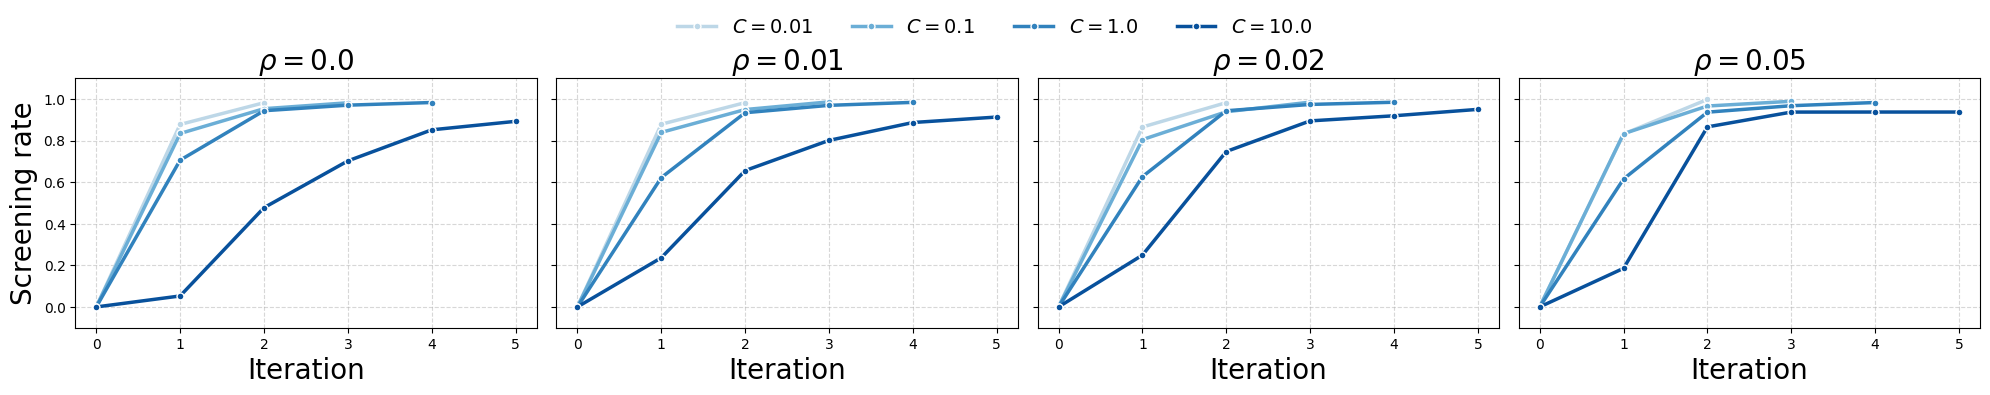

In [6]:
def plot_screening_progress_overlay(all_results, rho_list, C_list):

    blue_colors = [
        "#BDD7E7",
        "#6BAED6",
        "#3182BD",
        "#08519C"
    ]

    fig, axes = plt.subplots(
        1, len(rho_list),
        figsize=(20,4),
        sharey=True
    )

    if len(rho_list) == 1:
        axes = [axes]

    legend_handles = None

    for i, rho_val in enumerate(rho_list):
        ax = axes[i]

        for j, C_val in enumerate(C_list):

            result = [
                res for res in all_results
                if res["rho"] == rho_val and res["C"] == C_val
            ][0]

            history = result["history"]

            iterations = [h['iter'] for h in history]
            rates = [h['screening_rate'] for h in history]

            line, = ax.plot(
                iterations,
                rates,
                marker='o',
                markersize=5,
                markeredgecolor="white",
                linewidth=2.5,
                color=blue_colors[j],
                label=rf"$C={C_val}$"
            )

        # lưu legend từ subplot đầu
        if i == 0:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

        ax.set_title(rf"$\rho = {rho_val}$", fontsize=20)
        ax.set_xlabel("Iteration", fontsize=20)

        if i == 0:
            ax.set_ylabel("Screening rate", fontsize=20)

        ax.grid(True, linestyle="--", alpha=0.5)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    # ===== GLOBAL LEGEND =====
    fig.legend(
        legend_handles,
        legend_labels,
        loc="upper center",
        ncol=len(C_list),
        frameon=False,
        fontsize=14,
        bbox_to_anchor=(0.5, 1.0)
    )

    plt.ylim(-0.1, 1.1)

    plt.tight_layout(rect=[0, 0, 1, 0.92])

    plt.savefig(
        "screeningrate_spam.pdf",
        bbox_inches="tight"
    )

plot_screening_progress_overlay(all_results, rho_list, C_list)

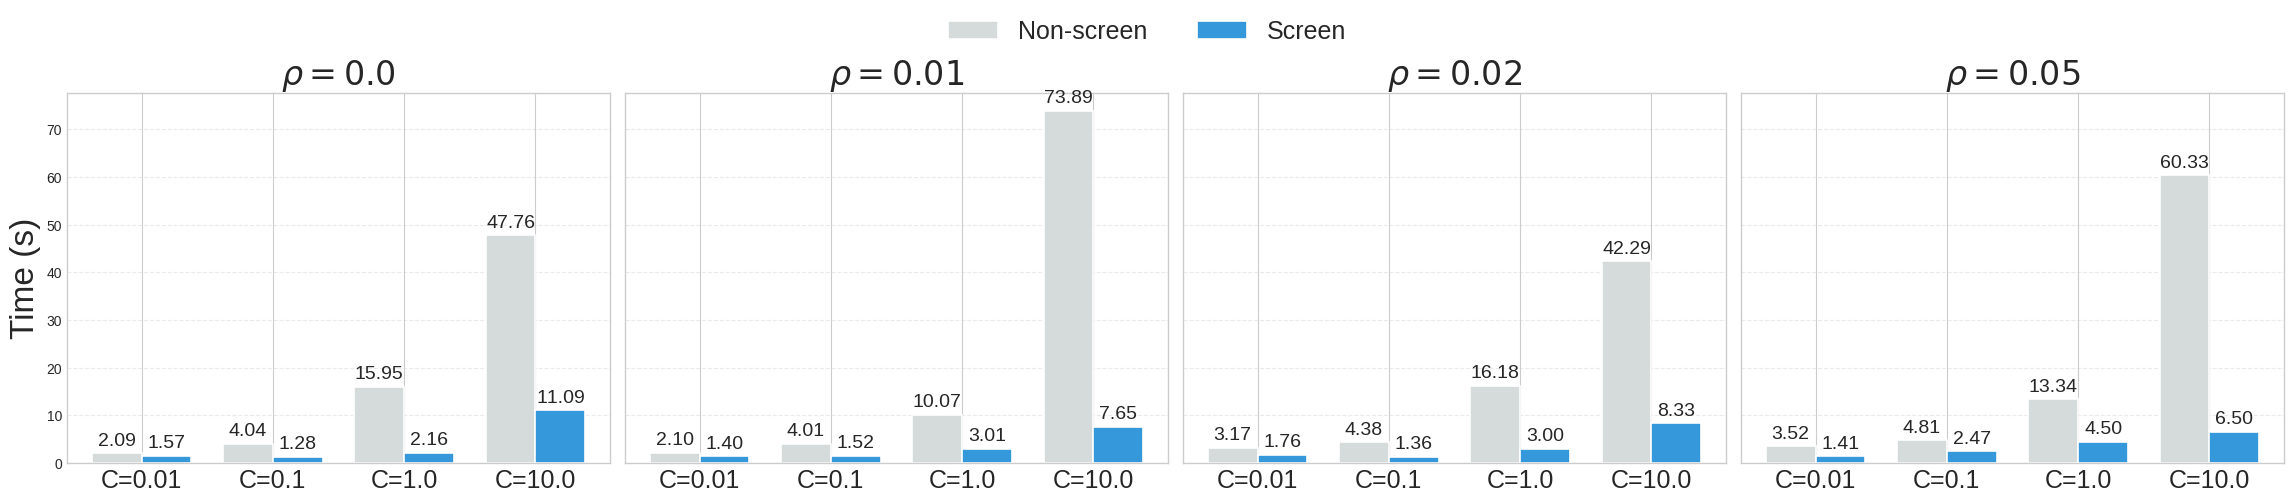

In [7]:
def plot_time_comparison(all_results, rho_list, C_list):

    plt.style.use("seaborn-v0_8-whitegrid")

    fig, axes = plt.subplots(
        1, len(rho_list),
        figsize=(24, 5),
        sharey=True
    )

    # ===== Colors =====
    color_full = "#D5DBDB"
    color_safe = "#3498DB"

    legend_handles = None

    for idx, rho_val in enumerate(rho_list):

        fig.subplots_adjust(wspace=0.12)
        ax = axes[idx]

        results_rho = [res for res in all_results if res["rho"] == rho_val]
        results_rho = sorted(results_rho, key=lambda x: x["C"])

        times_noscreen = [res["time_full"] for res in results_rho]
        times_screen = [res["time_safe"] for res in results_rho]

        x = np.arange(len(C_list))
        width = 0.38

        # ===== Bars =====
        bars1 = ax.bar(
            x - width/2,
            times_noscreen,
            width,
            label="Non-screen",
            color=color_full,
            edgecolor="white",
            linewidth=1.2
        )

        bars2 = ax.bar(
            x + width/2,
            times_screen,
            width,
            label="Screen",
            color=color_safe,
            edgecolor="white",
            linewidth=1.2
        )

        # ===== Show values on top of bars =====
        ax.bar_label(bars1, fmt="%.2f", padding=3, fontsize=14)
        ax.bar_label(bars2, fmt="%.2f", padding=3, fontsize=14)

        if idx == 0:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

        ax.set_xticks(x)
        ax.set_xticklabels([f"C={c}" for c in C_list], fontsize=18)

        ax.set_title(
            rf"$\rho = {rho_val}$",
            fontsize=24,
            weight="bold",
        )

        if idx == 0:
            ax.set_ylabel("Time (s)", fontsize=24)

        ax.grid(True, axis="y", linestyle="--", alpha=0.4)

        ax.spines["top"].set_visible(True)
        ax.spines["right"].set_visible(True)

        ax.spines["left"].set_color("#CCCCCC")
        ax.spines["bottom"].set_color("#CCCCCC")

    # ===== Global legend =====
    fig.legend(
        legend_handles,
        legend_labels,
        loc="upper center",
        ncol=2,
        frameon=False,
        fontsize=18,
        bbox_to_anchor=(0.5, 1.02)
    )

    plt.tight_layout(rect=[0.02, 0, 0.98, 0.93])

    plt.savefig(
        "time_spam.pdf",
        bbox_inches="tight"
    )

plot_time_comparison(all_results, rho_list, C_list)

In [8]:
def extract_time_and_elim_table(all_results, rho_list, C_list, scale=1):

    rows = []

    for rho_val in rho_list:
        for C_val in C_list:

            result = [
                res for res in all_results
                if res["rho"] == rho_val and res["C"] == C_val
            ][0]

            time_full = result["time_full"] * scale
            time_safe = result["time_safe"] * scale
            elim_rate = result["elim_rate"]

            speedup = (
                time_full / time_safe
                if time_safe > 0 else np.nan
            )

            rows.append([
                rho_val,
                C_val,
                time_full,
                time_safe,
                speedup,
                elim_rate
            ])

    df = pd.DataFrame(
        rows,
        columns=[
            "rho",
            "C",
            "Non-screen",
            "Screen",
            "Speedup",
            "Elimination Rate"
        ]
    )

    return df

df = extract_time_and_elim_table(all_results, rho_list, C_list)
print(df)

     rho      C  Non-screen     Screen   Speedup  Elimination Rate
0   0.00   0.01    2.087190   1.566987  1.331976          0.331450
1   0.00   0.10    4.043080   1.281044  3.156083          0.645729
2   0.00   1.00   15.954369   2.163714  7.373602          0.815910
3   0.00  10.00   47.761617  11.085886  4.308326          0.822865
4   0.01   0.01    2.098294   1.403313  1.495244          0.316888
5   0.01   0.10    4.010740   1.519377  2.639726          0.624429
6   0.01   1.00   10.070223   3.005273  3.350851          0.808303
7   0.01  10.00   73.891502   7.651791  9.656759          0.834819
8   0.02   0.01    3.165257   1.757791  1.800702          0.293849
9   0.02   0.10    4.378014   1.361151  3.216406          0.605086
10  0.02   1.00   16.177196   3.002263  5.388334          0.794175
11  0.02  10.00   42.293373   8.330623  5.076856          0.853510
12  0.05   0.01    3.522108   1.406881  2.503488          0.217127
13  0.05   0.10    4.814463   2.471131  1.948284          0.53